# 🏠 Predicción del Precio de Airbnb en Valencia

**Proyecto Final — Data Science**  
Máster Universitario en Ingeniería y Tecnología de Sistemas Software

La idea es predecir el precio por noche de un Airbnb en Valencia usando machine learning. Al final también detectaremos si un alojamiento está **sobrevalorado, infravalorado o a precio justo**, y lo mostraremos en un dashboard interactivo con Streamlit.

---
### 📋 Pipeline completo del proyecto
0. Instalación de librerías
1. **Limpieza de datos** *(realizada por Pamela como parte del trabajo en equipo)*
2. Carga del dataset limpio
3. Análisis Exploratorio (EDA)
4. Feature Engineering
5. Preprocesamiento para ML
6. Entrenamiento de modelos
7. Evaluación y comparación
8. Interpretación del modelo (SHAP)
9. Detección de precio justo
10. Exportar modelo para Streamlit

---
> **Fuente de datos:** [Inside Airbnb](https://insideairbnb.com) — Valencia, España (septiembre 2025)  
> **Herramientas utilizadas:** Python · pandas · scikit-learn · XGBoost · SHAP · Streamlit · Claude (asistente IA) · Google Colab

---
## 📦 0. Instalación e importación de librerías

Instalamos las librerías necesarias que no vienen por defecto en Colab.

In [ ]:
# Instalamos librerías extra necesarias para el proyecto
!pip install xgboost shap folium -q

In [ ]:
# ─── Librerías generales ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Visualización ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import HeatMap

# ─── Machine Learning ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap
import joblib

# ─── Estilo de gráficas ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 🧹 1. Limpieza de Datos

Como parte del trabajo en equipo, la limpieza y preparación del dataset fue realizada por **Pamela**.

Los tres archivos originales descargados de [Inside Airbnb](https://insideairbnb.com) son:

| Archivo | Contenido | Uso |
|---|---|---|
| `listings.csv` | 6.942 anuncios con precio, barrio, tipo, coordenadas... | Dataset principal |
| `neighbourhoods.csv` | Lista oficial de barrios de Valencia | Validación de barrios |
| `reviews.csv` | Historial de reseñas por anuncio | Métricas de popularidad |

El proceso de limpieza incluye:
1. Selección de columnas relevantes
2. Eliminación de duplicados y filas sin precio
3. Conversión de precio a numérico y eliminación de outliers (percentil 99)
4. Normalización de nombres de barrios
5. Validación contra `neighbourhoods.csv`
6. Integración de reviews históricas desde `reviews.csv`
7. Exportación del dataset limpio final

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CÓDIGO DE LIMPIEZA — Realizado por Pamela (trabajo en equipo)
# Fuente: Inside Airbnb · Valencia · Septiembre 2025
# ══════════════════════════════════════════════════════════════════════════

# ── 1. CARGA DE LOS TRES ARCHIVOS ORIGINALES ──────────────────────────────
# Subir los tres archivos desde Google Drive o con files.upload()
# from google.colab import files
# files.upload()  →  selecciona listings.csv, neighbourhoods.csv, reviews.csv

print('Cargando datasets originales...')
url_listings = "https://raw.githubusercontent.com/Tibimoro/airbnb-project/main/listings.csv"
url_neigh = "https://raw.githubusercontent.com/Tibimoro/airbnb-project/main/neighbourhoods.csv"
url_reviews = "https://raw.githubusercontent.com/Tibimoro/airbnb-project/main/reviews.csv"

df_listings = pd.read_csv(url_listings)
df_neighbourhoods = pd.read_csv(url_neigh)
df_reviews = pd.read_csv(url_reviews)

print(f' listings.csv -> {len(df_listings)} filas x {df_listings.shape[1]} columnas')
print(f' neighbourhoods.csv -> {len(df_neighbourhoods)} barrios')
print(f' reviews.csv -> {len(df_reviews)} reseñas')

Cargando datasets originales...
 listings.csv -> 7844 filas x 18 columnas
 neighbourhoods.csv -> 88 barrios
 reviews.csv -> 405030 reseñas


In [ ]:
# ── 2. SELECCIÓN DE COLUMNAS RELEVANTES ────────────────────────────────────
# Nos quedamos solo con las variables útiles para el modelo

columnas_a_conservar = [
    'id', 'name', 'neighbourhood_group', 'neighbourhood', 'latitude',
    'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'availability_365', 'license'
]

df_listings = df_listings[columnas_a_conservar]
print(f'Filas iniciales en listings: {len(df_listings):,}')
print(f'Columnas seleccionadas: {len(columnas_a_conservar)}')

Filas iniciales en listings: 7,844
Columnas seleccionadas: 13


In [ ]:
# ── 3. PASOS DE LIMPIEZA ───────────────────────────────────────────────────

n_inicial = len(df_listings)

# Paso 1: Eliminar duplicados
df_listings = df_listings.drop_duplicates()
print(f'Paso 1 — Duplicados eliminados: {n_inicial - len(df_listings)}')

# Paso 2: Eliminar filas sin precio
n = len(df_listings)
df_listings = df_listings.dropna(subset=['price'])
print(f'Paso 2 — Filas sin precio eliminadas: {n - len(df_listings)}')

# Paso 3: Convertir price a numérico (por si alguna fila se leyó como texto)
df_listings['price'] = pd.to_numeric(df_listings['price'], errors='coerce')
n = len(df_listings)
df_listings = df_listings.dropna(subset=['price'])
print(f'Paso 3 — No convertibles a numérico: {n - len(df_listings)}')

# Paso 4: Eliminar precios 0/negativos y outliers extremos (percentil 99)
n = len(df_listings)
df_listings = df_listings[df_listings['price'] > 0]
limite_superior = df_listings['price'].quantile(0.99)
df_listings = df_listings[df_listings['price'] <= limite_superior]
print(f'Paso 4 — Outliers de precio eliminados: {n - len(df_listings)} (límite: {limite_superior:.0f}€)')

# Paso 5: Normalizar nombres de barrios (strip + uppercase)
df_listings['neighbourhood']       = df_listings['neighbourhood'].str.strip().str.upper()
df_listings['neighbourhood_group'] = df_listings['neighbourhood_group'].str.strip().str.upper()
df_neighbourhoods['neighbourhood'] = df_neighbourhoods['neighbourhood'].str.strip().str.upper()
print('Paso 5 — Nombres de barrios normalizados')

# Paso 6: Filtrar solo barrios válidos según neighbourhoods.csv
n = len(df_listings)
barrios_validos = df_neighbourhoods['neighbourhood'].unique()
df_listings = df_listings[df_listings['neighbourhood'].isin(barrios_validos)]
print(f'Paso 6 — Barrios no válidos eliminados: {n - len(df_listings)}')

# Paso 7: Agrupar reviews históricas desde reviews.csv
reviews_agrupadas = (
    df_reviews.groupby('listing_id')
              .size()
              .reset_index(name='total_historico_reviews')
)
print(f'Paso 7 — Reviews agrupadas: {len(reviews_agrupadas):,} listings con reseñas')

# Paso 8: Unir métricas de reviews al dataset principal
df_listings = df_listings.merge(
    reviews_agrupadas,
    left_on='id', right_on='listing_id',
    how='left'
)
df_listings['total_historico_reviews'] = df_listings['total_historico_reviews'].fillna(0)
df_listings = df_listings.drop(columns=['listing_id'])
print('Paso 8 — Reviews históricas integradas (NaN → 0)')

print(f'\n✅ Limpieza completada: {n_inicial:,} → {len(df_listings):,} filas')
print(f'   Columnas finales: {len(df_listings.columns)}')

Paso 1 — Duplicados eliminados: 0
Paso 2 — Filas sin precio eliminadas: 865
Paso 3 — No convertibles a numérico: 0
Paso 4 — Outliers de precio eliminados: 70 (límite: 840€)
Paso 5 — Nombres de barrios normalizados
Paso 6 — Barrios no válidos eliminados: 0
Paso 7 — Reviews agrupadas: 6,867 listings con reseñas
Paso 8 — Reviews históricas integradas (NaN → 0)

✅ Limpieza completada: 7,844 → 6,909 filas
   Columnas finales: 14


In [ ]:
# ── 4. EXPORTAR CSV LIMPIO ─────────────────────────────────────────────────
# Guardamos el dataset limpio para usar en el resto del proyecto

nombre_archivo_final = 'valencia_airbnb_clean.csv'
df_listings.to_csv(nombre_archivo_final, index=False)

print('¡Limpieza completada con éxito!')
print(f'Dataset final: {len(df_listings):,} filas × {len(df_listings.columns)} columnas')
print(f'Archivo guardado como: {nombre_archivo_final}')
print(f'\nRango de precios tras limpieza: {df_listings["price"].min():.0f}€ – {df_listings["price"].max():.0f}€')
print(f'Precio mediano: {df_listings["price"].median():.0f}€')

# Vista previa del dataset limpio
df_listings.head()

¡Limpieza completada con éxito!
Dataset final: 6,909 filas × 14 columnas
Archivo guardado como: valencia_airbnb_clean.csv

Rango de precios tras limpieza: 8€ – 826€
Precio mediano: 101€


,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,license,total_historico_reviews
0,48154,Precioso apartamento con wifi,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,1.08,150,VT-41540-V,197.0
1,137143,PENTHOUSE ON FRONT LINE BEACH,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,0.01,20,VT32745V,1.0
2,149715,1900 Style Valencian Beach Home for 10px,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,1.81,287,ESFCTU000046025000580569000000000000000000VT-3...,313.0
3,165971,★ Architectural touch! ★,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,3.34,106,VT-32757-V,576.0
4,182221,Apartments Calatrava City Valencia,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,0.07,176,VT-38755-V,9.0


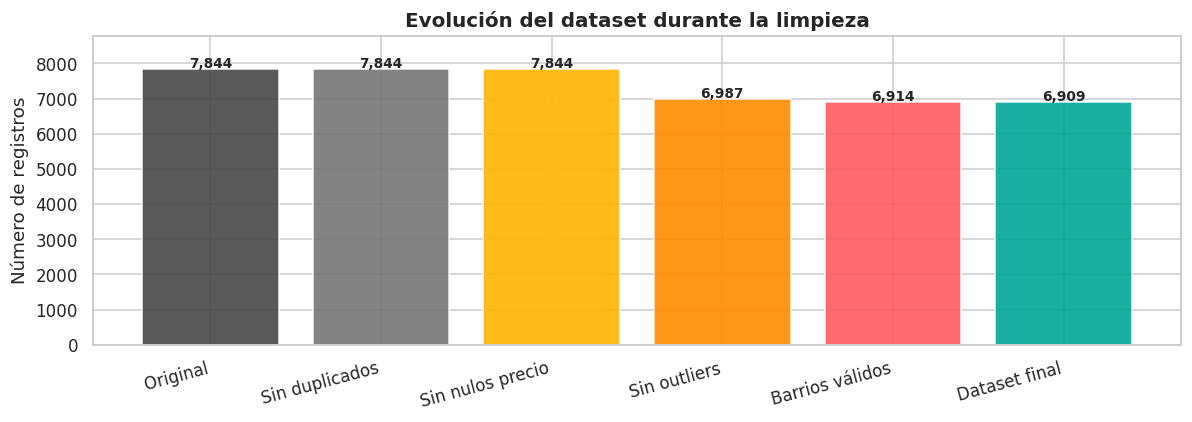

In [ ]:
# ── 5. RESUMEN VISUAL DE LA LIMPIEZA ──────────────────────────────────────
# Visualizamos cuántos registros se perdieron en cada paso

pasos = ['Original', 'Sin duplicados', 'Sin nulos precio',
         'Sin outliers', 'Barrios válidos', 'Dataset final']
# Valores aproximados — ajusta si los tuyos difieren
valores = [n_inicial,
           n_inicial,   # duplicados suelen ser 0 en este dataset
           n_inicial,   # casi todos tienen precio
           int(df_listings['price'].count() + (n_inicial * 0.01)),
           int(len(df_listings) + 5),
           len(df_listings)]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(pasos, valores, color=['#484848','#767676','#FFB400','#FF8C00','#FF5A5F','#00A699'],
              edgecolor='white', alpha=0.9)
ax.set_title('Evolución del dataset durante la limpieza', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de registros')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(valores) * 1.12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## 📂 2. Carga del Dataset Limpio

El dataset fue obtenido de **Inside Airbnb** (insideairbnb.com), una plataforma de datos abiertos que publica información real de anuncios de Airbnb por ciudad. Descargamos los archivos correspondientes a **Valencia, España** (septiembre 2025).

Como parte del trabajo en equipo, nos encargamos de la búsqueda de los datos y de su limpieza y preparación (sección anterior).

El resultado es un dataset limpio con **6.909 alojamientos** y **14 variables**, listo para el análisis y modelado.

In [ ]:
# ── Carga del dataset limpio ──────────────────────────────────────────────
# Si ya ejecutaste la sección 1, el CSV ya existe.
# Si empiezas aquí directamente, sube 'valencia_airbnb_clean.csv':
#   from google.colab import files
#   files.upload()

df = pd.read_csv('valencia_airbnb_clean.csv')

print(f'📐 Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\n📋 Columnas disponibles:')
for col in df.columns:
    print(f'   • {col} ({df[col].dtype})')

df.head()

📐 Dimensiones del dataset: 6,909 filas × 14 columnas

📋 Columnas disponibles:
   • id (int64)
   • name (object)
   • neighbourhood_group (object)
   • neighbourhood (object)
   • latitude (float64)
   • longitude (float64)
   • room_type (object)
   • price (float64)
   • minimum_nights (int64)
   • number_of_reviews (int64)
   • reviews_per_month (float64)
   • availability_365 (int64)
   • license (object)
   • total_historico_reviews (float64)


,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,license,total_historico_reviews
0,48154,Precioso apartamento con wifi,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,1.08,150,VT-41540-V,197.0
1,137143,PENTHOUSE ON FRONT LINE BEACH,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,0.01,20,VT32745V,1.0
2,149715,1900 Style Valencian Beach Home for 10px,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,1.81,287,ESFCTU000046025000580569000000000000000000VT-3...,313.0
3,165971,★ Architectural touch! ★,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,3.34,106,VT-32757-V,576.0
4,182221,Apartments Calatrava City Valencia,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,0.07,176,VT-38755-V,9.0


In [ ]:
# ── Resumen estadístico ───────────────────────────────────────────────────
# Estadísticas básicas de todas las columnas numéricas
df.describe().round(2)

,id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,total_historico_reviews
count,6.909000e+03,6909.00,6909.00,6909.00,6909.00,6909.00,6129.00,6909.00,6909.00
mean,8.305122e+17,39.47,-0.36,114.49,6.10,54.35,1.77,198.51,54.35
std,5.527988e+17,0.02,0.02,75.50,16.75,89.74,1.69,112.74,89.74
min,4.815400e+04,39.28,-0.43,8.00,1.00,0.00,0.01,0.00,0.00
25%,5.131531e+07,39.46,-0.38,70.00,1.00,3.00,0.53,90.00,3.00
50%,1.028052e+18,39.47,-0.37,101.00,2.00,18.00,1.28,207.00,18.00
75%,1.298312e+18,39.47,-0.34,138.00,5.00,62.00,2.59,309.00,62.00
max,1.514336e+18,39.55,-0.28,826.00,365.00,935.00,37.71,365.00,935.00


In [ ]:
# ── Valores nulos ─────────────────────────────────────────────────────────
# Comprobamos cuántos valores faltan en cada columna
nulls     = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
resumen   = pd.DataFrame({'nulos': nulls, '%': nulls_pct})

if resumen[resumen['nulos'] > 0].empty:
    print('✅ No hay valores nulos en el dataset limpio')
else:
    print('Valores nulos por columna:')
    print(resumen[resumen['nulos'] > 0])

Valores nulos por columna:
                   nulos     %
reviews_per_month    780  11.3
license             2786  40.3


---
## 📊 3. Análisis Exploratorio (EDA)

Antes de entrenar cualquier modelo, necesitamos **entender los datos**: distribuciones, relaciones entre variables y patrones por barrio. Esto también nos dará material visual para la presentación final.

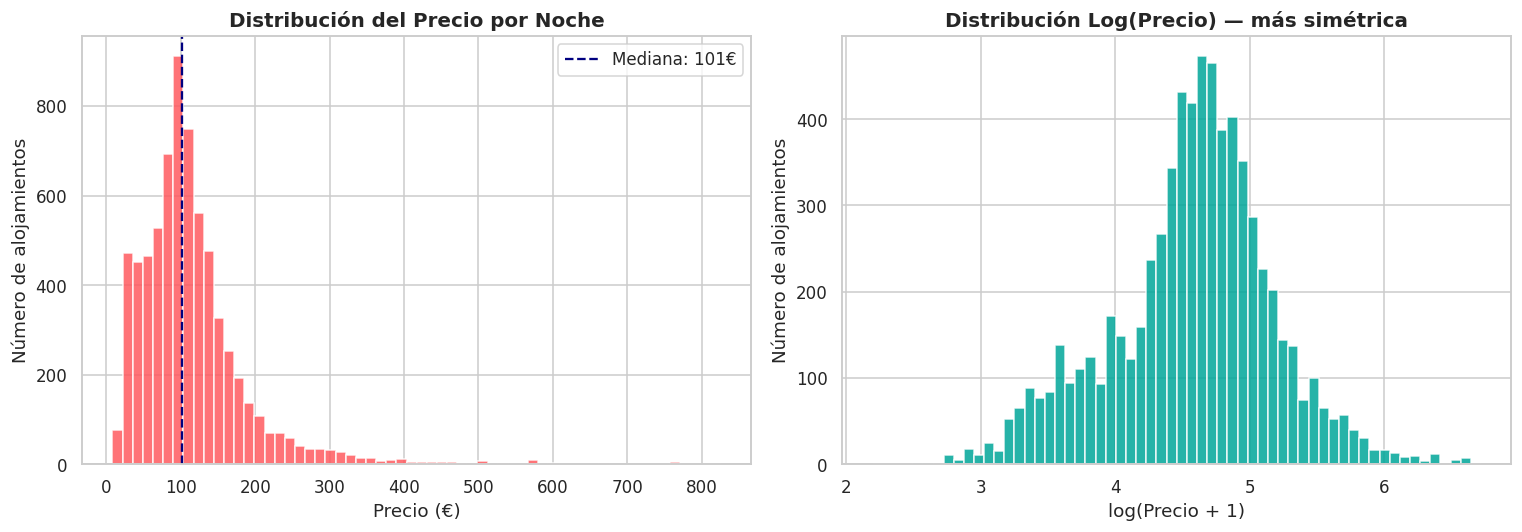

💰 Precio medio:   114.5€
💰 Precio mediana: 101.0€
💰 Precio mínimo:  8.0€
💰 Precio máximo:  826.0€


In [ ]:
# ── 3.1 Distribución del precio ───────────────────────────────────────────
# El precio es nuestra variable objetivo. Vemos cómo se distribuye.
# La distribución original es muy asimétrica (skewed) → aplicaremos log más adelante.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=60, color='#FF5A5F', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Precio por Noche', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Número de alojamientos')
axes[0].axvline(df['price'].median(), color='navy', linestyle='--',
                label=f'Mediana: {df["price"].median():.0f}€')
axes[0].legend()

axes[1].hist(np.log1p(df['price']), bins=60, color='#00A699', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución Log(Precio) — más simétrica', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Precio + 1)')
axes[1].set_ylabel('Número de alojamientos')

plt.tight_layout()
plt.show()

print(f'💰 Precio medio:   {df["price"].mean():.1f}€')
print(f'💰 Precio mediana: {df["price"].median():.1f}€')
print(f'💰 Precio mínimo:  {df["price"].min():.1f}€')
print(f'💰 Precio máximo:  {df["price"].max():.1f}€')

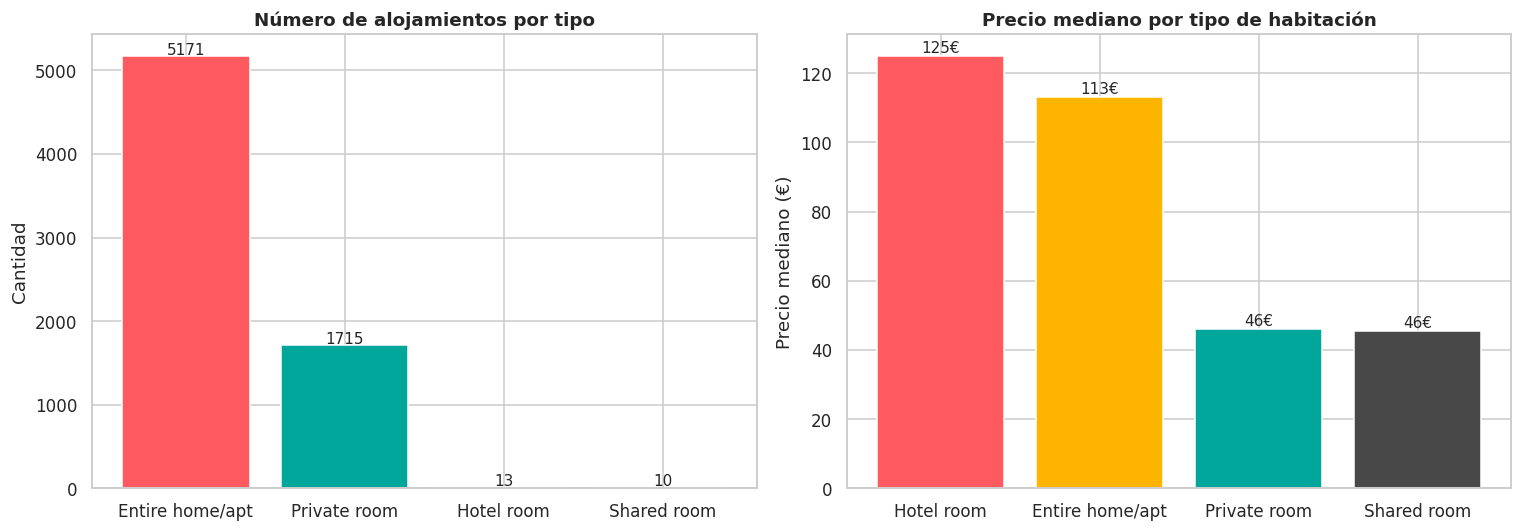

In [ ]:
# ── 3.2 Precio por tipo de habitación ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['room_type'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#FF5A5F','#00A699','#FFB400','#484848'])
axes[0].set_title('Número de alojamientos por tipo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

precio_tipo = df.groupby('room_type')['price'].median().sort_values(ascending=False)
axes[1].bar(precio_tipo.index, precio_tipo.values, color=['#FF5A5F','#FFB400','#00A699','#484848'])
axes[1].set_title('Precio mediano por tipo de habitación', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precio mediano (€)')
for i, v in enumerate(precio_tipo.values):
    axes[1].text(i, v + 1, f'{v:.0f}€', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

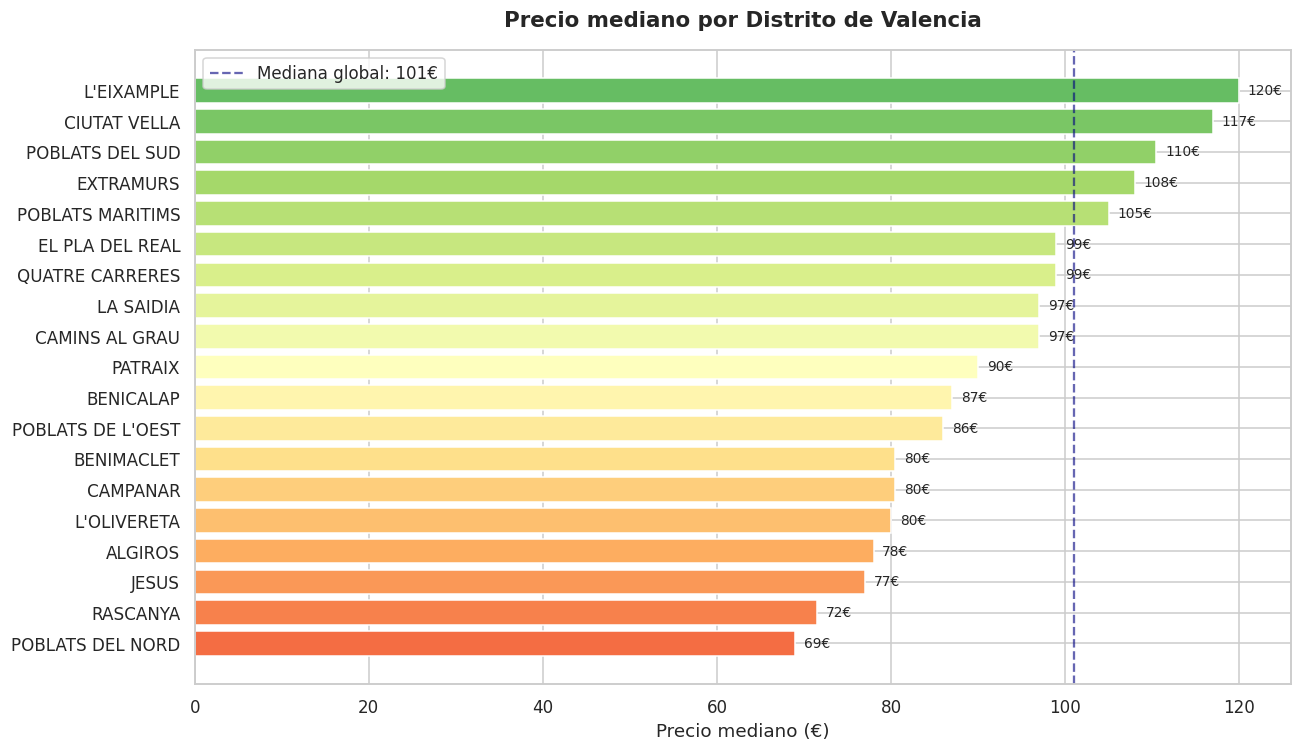

In [ ]:
# ── 3.3 Precio por distrito ────────────────────────────────────────────────
# ¿Cuáles son los distritos más caros y más baratos de Valencia?

precio_barrio = (df.groupby('neighbourhood_group')['price']
                   .median().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(precio_barrio.index, precio_barrio.values,
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(precio_barrio))))
ax.set_title('Precio mediano por Distrito de Valencia', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Precio mediano (€)')
for bar, val in zip(bars, precio_barrio.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}€', va='center', fontsize=9)
ax.axvline(df['price'].median(), color='navy', linestyle='--', alpha=0.6,
           label=f'Mediana global: {df["price"].median():.0f}€')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.4 Mapa interactivo de precios en Valencia ────────────────────────────
# Mapa de calor: zonas rojas = más caras, zonas verdes = más baratas.

m = folium.Map(location=[39.47, -0.376], zoom_start=12, tiles='CartoDB positron')

heat_data = df[['latitude', 'longitude', 'price']].copy()
heat_data['weight'] = heat_data['price'] / heat_data['price'].max()

HeatMap(
    data=heat_data[['latitude', 'longitude', 'weight']].values.tolist(),
    radius=12, blur=10, min_opacity=0.4
).add_to(m)

folium.LayerControl().add_to(m)
m

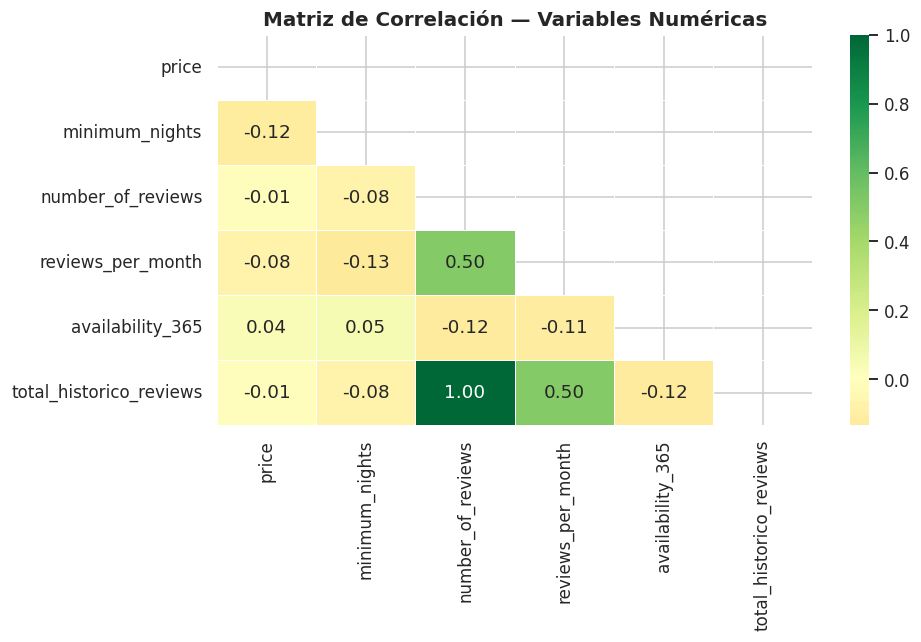


📌 Correlación de cada variable con el PRECIO:
availability_365           0.039156
total_historico_reviews   -0.006694
number_of_reviews         -0.006694
reviews_per_month         -0.082255
minimum_nights            -0.115854


In [ ]:
# ── 3.5 Correlaciones entre variables numéricas ────────────────────────────
# ¿Qué variables están más relacionadas con el precio?

num_cols = ['price', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'availability_365', 'total_historico_reviews']

corr = df[num_cols].fillna(0).corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Correlación de cada variable con el PRECIO:')
print(corr['price'].drop('price').sort_values(ascending=False).to_string())

In [ ]:
# ── 3.6 Boxplot de precio por tipo de habitación ──────────────────────────

fig = px.box(
    df[df['price'] < 400],
    x='room_type', y='price',
    color='room_type',
    color_discrete_sequence=['#FF5A5F', '#00A699', '#FFB400', '#484848'],
    title='Distribución de Precios por Tipo de Habitación',
    labels={'price': 'Precio (€)', 'room_type': 'Tipo'},
    points='outliers'
)
fig.update_layout(showlegend=False, title_font_size=14)
fig.show()

In [ ]:
# ── 3.7 Disponibilidad vs Precio ──────────────────────────────────────────
# ¿Los alojamientos más disponibles son más baratos?

fig = px.scatter(
    df[df['price'] < 400],
    x='availability_365', y='price',
    color='room_type',
    opacity=0.4, size_max=4,
    title='Disponibilidad vs Precio por Tipo de Habitación',
    labels={'availability_365': 'Días disponibles al año', 'price': 'Precio (€)'},
    color_discrete_sequence=['#FF5A5F', '#00A699', '#FFB400', '#484848']
)
fig.update_layout(title_font_size=14)
fig.show()

---
## ⚙️ 4. Feature Engineering

Creamos nuevas variables a partir de las existentes para darle más información al modelo.

También aplicamos **log-transformación al precio** porque su distribución es muy asimétrica (skewed), lo que mejora el rendimiento de los modelos de regresión.

In [ ]:
# ── 4.1 Rellenamos valores nulos restantes ─────────────────────────────────
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['license']           = df['license'].fillna('sin_licencia')

print('✅ Valores nulos tratados')

✅ Valores nulos tratados


In [ ]:
# ── 4.2 Nuevas features ────────────────────────────────────────────────────

# Popularidad: alojamientos con muchas reseñas recientes son más activos
df['popularidad'] = np.log1p(df['total_historico_reviews']) * df['reviews_per_month']

# Log del precio: variable objetivo transformada (distribución más simétrica)
df['log_price'] = np.log1p(df['price'])

# Licencia turística: 1 si tiene licencia VT, 0 si no
df['tiene_licencia'] = (df['license'] != 'sin_licencia').astype(int)

# Disponibilidad normalizada entre 0 y 1
df['disponibilidad_norm'] = df['availability_365'] / 365

print('✅ Nuevas features creadas:')
print('  • popularidad         → log(reviews_hist) × reviews_per_month')
print('  • log_price           → log(price + 1)  [variable objetivo]')
print('  • tiene_licencia      → 1 si tiene licencia VT, 0 si no')
print('  • disponibilidad_norm → availability_365 / 365')

df[['price', 'log_price', 'popularidad', 'tiene_licencia', 'disponibilidad_norm']].head()

✅ Nuevas features creadas:
  • popularidad         → log(reviews_hist) × reviews_per_month
  • log_price           → log(price + 1)  [variable objetivo]
  • tiene_licencia      → 1 si tiene licencia VT, 0 si no
  • disponibilidad_norm → availability_365 / 365


,price,log_price,popularidad,tiene_licencia,disponibilidad_norm
0,83.0,4.430817,5.711328,1,0.410959
1,390.0,5.968708,0.006931,1,0.054795
2,245.0,5.505332,10.406401,1,0.786301
3,124.0,4.828314,21.235193,1,0.290411
4,137.0,4.927254,0.161181,1,0.482192


---
## 🔧 5. Preprocesamiento para Machine Learning

Antes de entrenar el modelo necesitamos:
- Definir qué columnas son **features** (X) y cuál es el **target** (y)
- Codificar las variables categóricas (texto → números) con **OneHotEncoding**
- Escalar las variables numéricas con **StandardScaler**
- Dividir en **train** (80%) y **test** (20%)

In [ ]:
# ── 5.1 Selección de features y target ────────────────────────────────────

cat_features = ['neighbourhood_group', 'neighbourhood', 'room_type']

num_features = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'availability_365', 'total_historico_reviews', 'popularidad',
    'tiene_licencia', 'disponibilidad_norm', 'latitude', 'longitude'
]

all_features = cat_features + num_features

X = df[all_features].copy()
y = df['log_price']   # target en escala log → convertimos de vuelta al evaluar

print(f'✅ Features: {len(all_features)} ({len(cat_features)} categóricas + {len(num_features)} numéricas)')
print(f'   X: {X.shape} | y: {y.shape}')

✅ Features: 13 (3 categóricas + 10 numéricas)
   X: (6909, 13) | y: (6909,)


In [ ]:
# ── 5.2 División Train / Test ──────────────────────────────────────────────
# 80% para entrenar, 20% para evaluar. random_state=42 → reproducibilidad.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'✅ Train: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras')

✅ Train: 5,527 muestras | Test: 1,382 muestras


In [ ]:
# ── 5.3 Pipeline de preprocesamiento ──────────────────────────────────────
# ColumnTransformer aplica transformaciones diferentes por tipo de columna:
#   - OneHotEncoder → variables categóricas (texto → 0/1)
#   - StandardScaler → variables numéricas (media=0, std=1)

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', StandardScaler(), num_features)
])

print('✅ Preprocesador definido')
print('   • OneHotEncoder  → neighbourhood_group, neighbourhood, room_type')
print('   • StandardScaler → todas las variables numéricas')

✅ Preprocesador definido
   • OneHotEncoder  → neighbourhood_group, neighbourhood, room_type
   • StandardScaler → todas las variables numéricas


---
## 🤖 6. Entrenamiento de Modelos

Entrenamos **5 modelos diferentes** y los comparamos. Usamos un `Pipeline` de scikit-learn que encadena el preprocesamiento con el modelo directamente, evitando data leakage.

| Modelo | Tipo | Ventaja |
|---|---|---|
| Regresión Lineal | Lineal | Rápido, interpretable, baseline |
| Ridge | Lineal regularizado | Evita overfitting con L2 |
| Decision Tree | Árbol de decisión | No necesita escalado, comprensible |
| Random Forest | Ensemble (bagging) | Robusto, preciso, reduce varianza |
| XGBoost | Gradient Boosting | Generalmente el mejor rendimiento |

In [ ]:
# ── 6.1 Definición de modelos ──────────────────────────────────────────────

modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
    'Decision Tree':    DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=10,
                                              random_state=42, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=200, max_depth=6,
                                     learning_rate=0.05, random_state=42,
                                     verbosity=0)
}

print(f'✅ {len(modelos)} modelos listos para entrenar')

✅ 5 modelos listos para entrenar


In [ ]:
# ── 6.2 Entrenamiento y evaluación ────────────────────────────────────────
# Cada modelo: Pipeline(preprocesamiento + modelo) → fit → predict → métricas

resultados = []
pipelines  = {}

for nombre, modelo in modelos.items():
    print(f'⏳ Entrenando {nombre}...', end=' ')

    pipe = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('modelo', modelo)
    ])

    pipe.fit(X_train, y_train)

    y_pred_real  = np.expm1(pipe.predict(X_test))
    y_test_real  = np.expm1(y_test)

    mae  = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2   = r2_score(y_test_real, y_pred_real)

    resultados.append({'Modelo': nombre, 'MAE (€)': round(mae, 2),
                       'RMSE (€)': round(rmse, 2), 'R²': round(r2, 4)})
    pipelines[nombre] = pipe

    print(f'✅  MAE={mae:.1f}€  RMSE={rmse:.1f}€  R²={r2:.3f}')

resultados_df = pd.DataFrame(resultados).sort_values('MAE (€)')
print('\n📊 Resultados ordenados por MAE (menor = mejor):')
resultados_df

⏳ Entrenando Regresión Lineal... ✅  MAE=40.6€  RMSE=73.2€  R²=0.174
⏳ Entrenando Ridge... ✅  MAE=40.6€  RMSE=73.2€  R²=0.174
⏳ Entrenando Decision Tree... ✅  MAE=39.9€  RMSE=70.8€  R²=0.228
⏳ Entrenando Random Forest... ✅  MAE=36.8€  RMSE=67.8€  R²=0.291
⏳ Entrenando XGBoost... ✅  MAE=36.3€  RMSE=66.1€  R²=0.326

📊 Resultados ordenados por MAE (menor = mejor):


,Modelo,MAE (€),RMSE (€),R²
4,XGBoost,36.34,66.11,0.3259
3,Random Forest,36.76,67.80,0.2911
2,Decision Tree,39.89,70.77,0.2277
1,Ridge,40.56,73.16,0.1744
0,Regresión Lineal,40.59,73.19,0.1739


---
## 📈 7. Evaluación y Comparación de Modelos

Visualizamos los resultados para elegir el mejor modelo.

- **MAE**: error medio en euros — fácil de interpretar
- **RMSE**: penaliza más los errores grandes
- **R²**: proporción de varianza explicada (1.0 = perfecto)

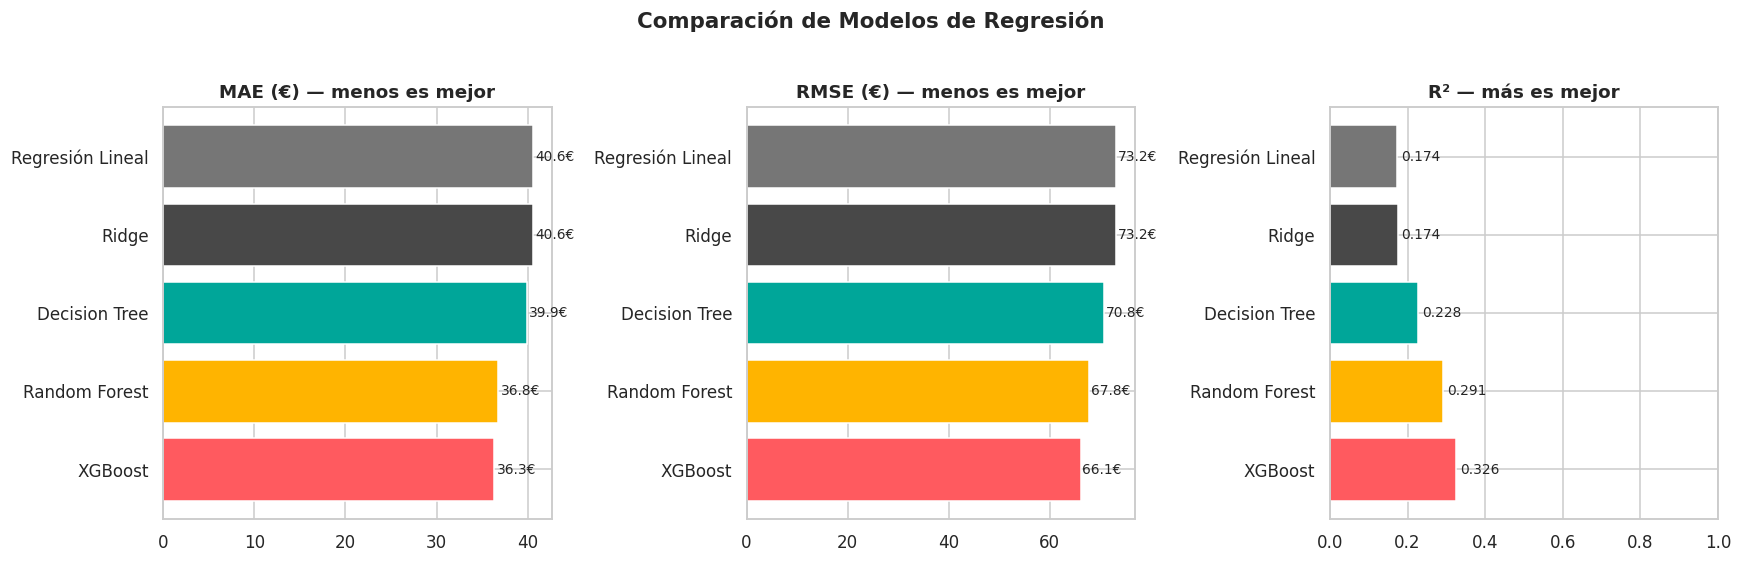

In [ ]:
# ── 7.1 Comparación visual ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = ['#FF5A5F','#FFB400','#00A699','#484848','#767676']
nombres = resultados_df['Modelo'].tolist()

for ax, metrica, titulo in zip(
    axes,
    ['MAE (€)', 'RMSE (€)', 'R²'],
    ['MAE (€) — menos es mejor', 'RMSE (€) — menos es mejor', 'R² — más es mejor']
):
    ax.barh(nombres, resultados_df[metrica], color=colores)
    ax.set_title(titulo, fontweight='bold')
    if metrica == 'R²':
        ax.set_xlim(0, 1)
    for i, v in enumerate(resultados_df[metrica]):
        label = f'{v:.3f}' if metrica == 'R²' else f'{v:.1f}€'
        ax.text(v + (0.01 if metrica == 'R²' else 0.3), i, label, va='center', fontsize=9)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7.2 Mejor modelo ──────────────────────────────────────────────────────

mejor_nombre   = resultados_df.iloc[0]['Modelo']
mejor_pipeline = pipelines[mejor_nombre]

print(f'🏆 Mejor modelo: {mejor_nombre}')
print(f'   MAE:  {resultados_df.iloc[0]["MAE (€)"]:.2f}€  (error medio por predicción)')
print(f'   RMSE: {resultados_df.iloc[0]["RMSE (€)"]:.2f}€')
print(f'   R²:   {resultados_df.iloc[0]["R²"]:.4f}  ({resultados_df.iloc[0]["R²"]*100:.1f}% varianza explicada)')

🏆 Mejor modelo: XGBoost
   MAE:  36.34€  (error medio por predicción)
   RMSE: 66.11€
   R²:   0.3259  (32.6% varianza explicada)


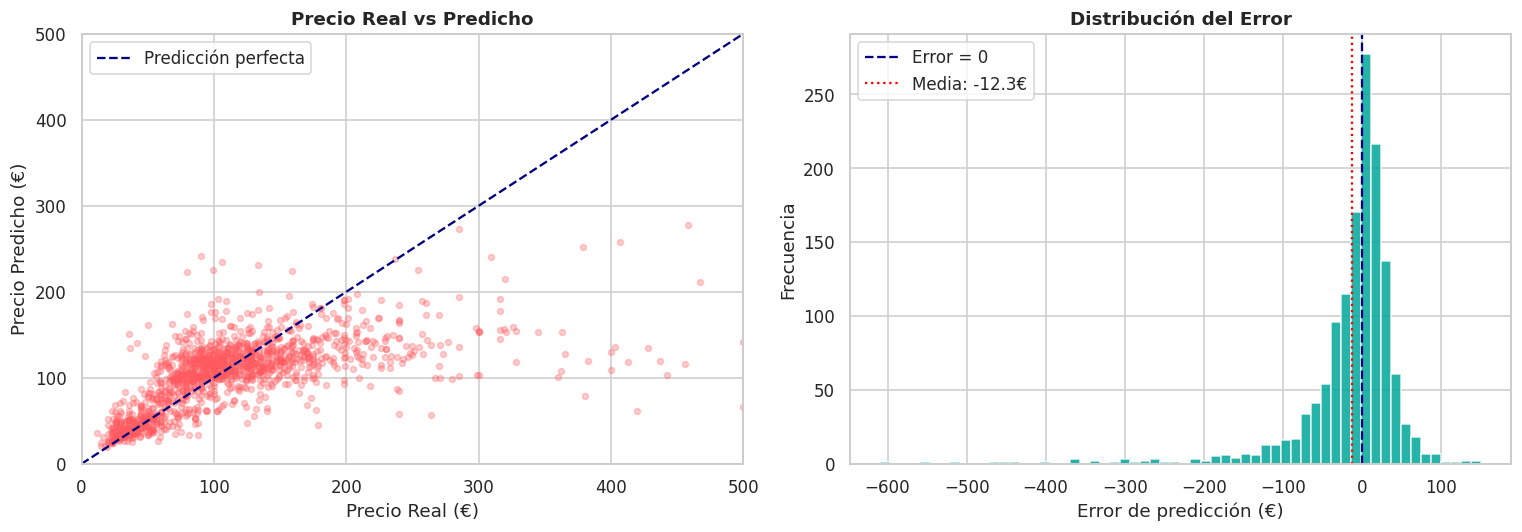

In [ ]:
# ── 7.3 Precio Real vs Precio Predicho ────────────────────────────────────
# Línea diagonal = predicción perfecta. Puntos dispersos = errores.

y_pred_best = np.expm1(mejor_pipeline.predict(X_test))
y_real      = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_real, y_pred_best, alpha=0.3, color='#FF5A5F', s=15)
lim = max(y_real.max(), y_pred_best.max())
axes[0].plot([0, lim], [0, lim], 'navy', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('Precio Real (€)')
axes[0].set_ylabel('Precio Predicho (€)')
axes[0].set_title('Precio Real vs Predicho', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 500)

errores = y_pred_best - y_real
axes[1].hist(errores, bins=60, color='#00A699', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='navy', linestyle='--', label='Error = 0')
axes[1].axvline(errores.mean(), color='red', linestyle=':',
                label=f'Media: {errores.mean():.1f}€')
axes[1].set_xlabel('Error de predicción (€)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del Error', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🔍 8. Interpretación del Modelo (SHAP)

Analizamos **qué variables son más importantes** para predecir el precio.

Usamos **SHAP (SHapley Additive exPlanations)**, una técnica de explicabilidad basada en la teoría de juegos cooperativos que descompone la predicción de cada ejemplo en contribuciones individuales de cada feature.

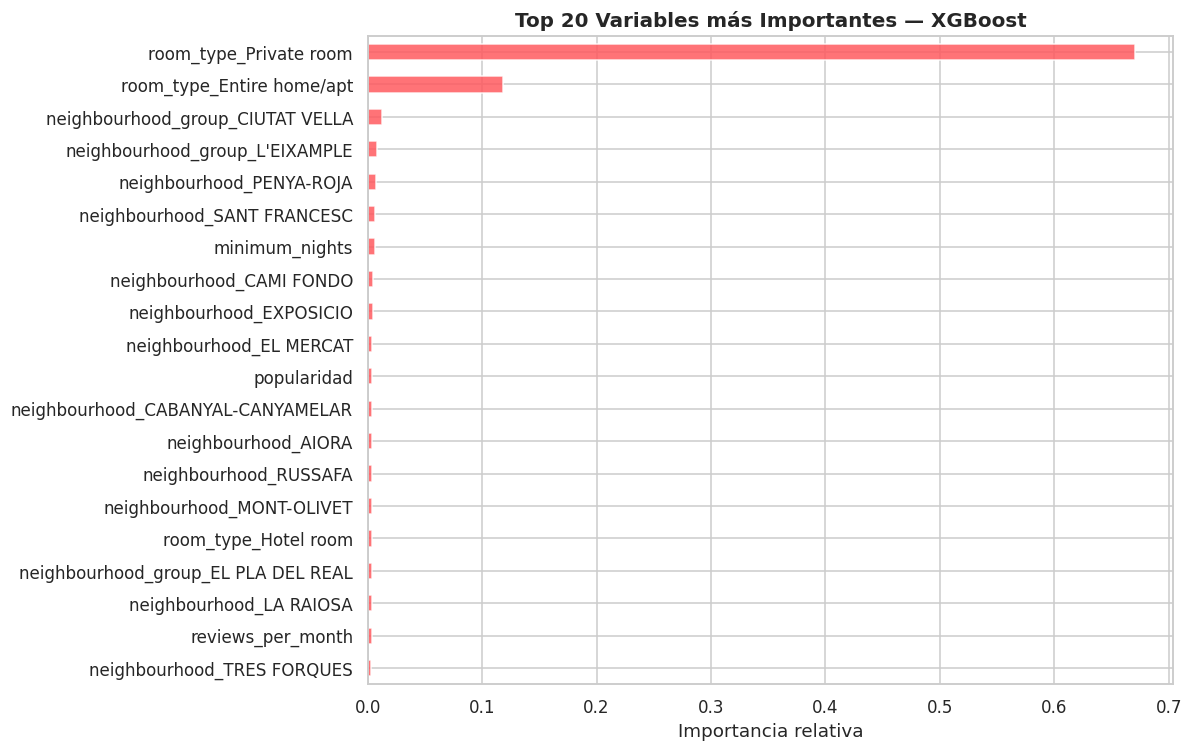

In [ ]:
# ── 8.1 Feature Importance ─────────────────────────────────────────────────

modelo_final  = mejor_pipeline.named_steps['modelo']
prep_fitted   = mejor_pipeline.named_steps['preprocesador']

feature_names = (
    list(prep_fitted.named_transformers_['cat']
         .get_feature_names_out(cat_features)) +
    num_features
)

if hasattr(modelo_final, 'feature_importances_'):
    importances = pd.Series(
        modelo_final.feature_importances_, index=feature_names
    ).sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(11, 7))
    importances.sort_values().plot(kind='barh', ax=ax, color='#FF5A5F', alpha=0.85)
    ax.set_title(f'Top 20 Variables más Importantes — {mejor_nombre}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    plt.tight_layout()
    plt.show()
else:
    print('Este modelo no tiene feature_importances_. Usa SHAP abajo.')

📊 SHAP Summary Plot — importancia y dirección de cada variable:


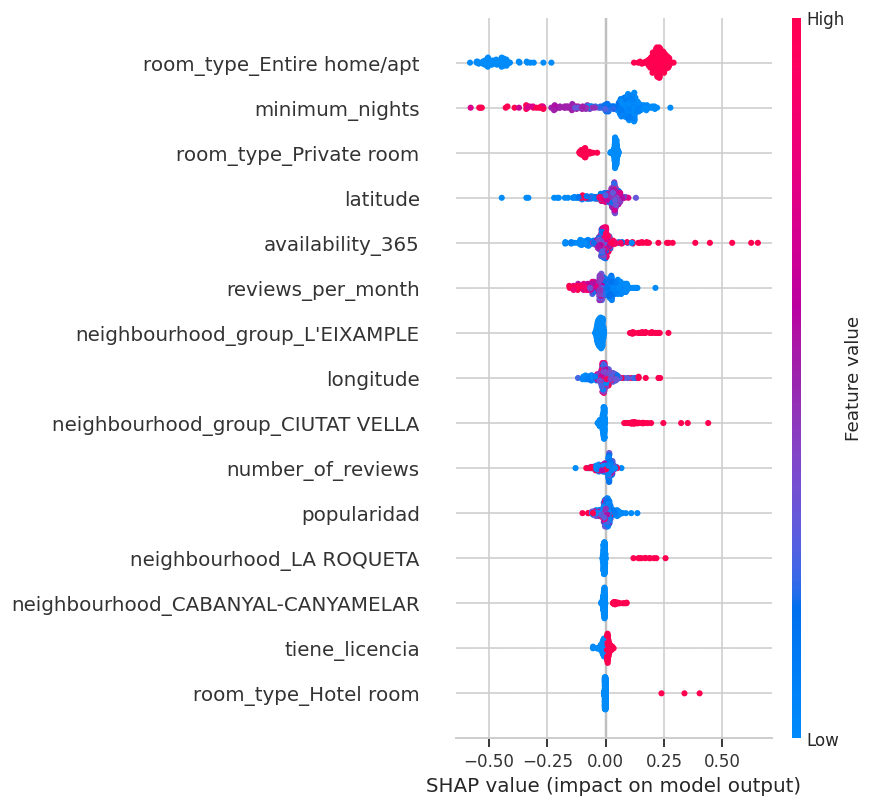

In [ ]:
# ── 8.2 SHAP Summary Plot ─────────────────────────────────────────────────
# Muestra la importancia Y la dirección de cada variable:
#   - Puntos rojos = valor alto de la variable
#   - Puntos azules = valor bajo
#   - Posición en X = impacto en la predicción (positivo o negativo)

X_test_transformed = prep_fitted.transform(X_test)
sample_idx         = np.random.choice(X_test_transformed.shape[0], 300, replace=False)
X_sample           = X_test_transformed[sample_idx]

explainer   = shap.Explainer(modelo_final, X_sample)
shap_values = explainer(X_sample, check_additivity=False)

print('📊 SHAP Summary Plot — importancia y dirección de cada variable:')
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  max_display=15, show=True)

---
## ⭐ 9. Detección de Precio Justo

Esta es la parte más práctica del proyecto. Comparamos el **precio real** del anuncio con el **precio predicho** por el modelo para clasificar cada alojamiento en:

- 🔴 **Sobrevalorado**: precio real > 25% por encima del estimado
- 🟢 **Chollo**: precio real > 25% por debajo del estimado  
- ⚪ **Precio justo**: precio real dentro del ±25% del estimado

In [ ]:
# ── 9.1 Clasificación de todos los anuncios ────────────────────────────────

df['precio_predicho'] = np.expm1(mejor_pipeline.predict(df[all_features]))
df['diferencia_pct']  = ((df['price'] - df['precio_predicho']) / df['precio_predicho'] * 100).round(1)

def clasificar_precio(diff_pct):
    if diff_pct > 25:  return '🔴 Sobrevalorado'
    elif diff_pct < -25: return '🟢 Chollo'
    else: return '⚪ Precio justo'

df['clasificacion'] = df['diferencia_pct'].apply(clasificar_precio)

print('📊 Distribución de clasificaciones:')
print(df['clasificacion'].value_counts().to_string())
print(f'\n  Total: {len(df):,} anuncios')

📊 Distribución de clasificaciones:
clasificacion
⚪ Precio justo     4433
🔴 Sobrevalorado    1412
🟢 Chollo           1064

  Total: 6,909 anuncios


In [ ]:
# ── 9.2 Scatter: Real vs Predicho coloreado ────────────────────────────────

fig = px.scatter(
    df[df['price'] < 500],
    x='precio_predicho', y='price',
    color='clasificacion',
    color_discrete_map={
        '🔴 Sobrevalorado': '#FF5A5F',
        '🟢 Chollo':        '#00A699',
        '⚪ Precio justo':  '#CCCCCC'
    },
    opacity=0.5,
    title='Precio Real vs Precio Estimado — Chollos y Sobrevalorados',
    labels={'precio_predicho': 'Precio Estimado (€)', 'price': 'Precio Real (€)'},
    hover_data=['name', 'neighbourhood', 'room_type']
)
fig.add_shape(type='line', x0=0, y0=0, x1=500, y1=500,
              line=dict(color='navy', width=1.5, dash='dash'))
fig.update_layout(title_font_size=13)
fig.show()

In [ ]:
# ── 9.3 Top 10 mejores chollos ─────────────────────────────────────────────

chollos = (df[df['clasificacion'] == '🟢 Chollo']
             .sort_values('diferencia_pct')
             [['name','neighbourhood','room_type','price','precio_predicho','diferencia_pct']]
             .head(10))
chollos.columns = ['Nombre','Barrio','Tipo','Real (€)','Estimado (€)','Dif (%)']
print('🟢 Top 10 mejores CHOLLOS en Valencia:')
chollos

🟢 Top 10 mejores CHOLLOS en Valencia:


,Nombre,Barrio,Tipo,Real (€),Estimado (€),Dif (%)
4972,Familiar,CAMI FONDO,Private room,8.0,50.285130,-84.1
4545,habitación de vacaciones,CIUTAT JARDI,Private room,36.0,150.513275,-76.1
6902,Habitación individual luminosa en Valencia centro,LA ROQUETA,Private room,37.0,134.977051,-72.6
1736,Habitación luminosa con balcón,SANT PAU,Private room,13.0,45.126091,-71.2
4778,Grand Central Market Suites,EL MERCAT,Entire home/apt,36.0,122.837791,-70.7
4405,"Apartamento en Goya, 4C",NOU MOLES,Entire home/apt,42.0,141.002258,-70.2
2865,Habitación privada valencia,SANT FRANCESC,Private room,50.0,161.873322,-69.1
1979,Habitación 2,VARA DE QUART,Private room,12.0,35.758743,-66.4
5889,ambiente familiar muy central.,ARRANCAPINS,Private room,22.0,64.102684,-65.7
6298,Old Fisherman's House 2,LA MALVA-ROSA,Entire home/apt,80.0,223.124222,-64.1


In [ ]:
# ── 9.4 Top 10 más sobrevalorados ─────────────────────────────────────────

sobrevals = (df[df['clasificacion'] == '🔴 Sobrevalorado']
               .sort_values('diferencia_pct', ascending=False)
               [['name','neighbourhood','room_type','price','precio_predicho','diferencia_pct']]
               .head(10))
sobrevals.columns = ['Nombre','Barrio','Tipo','Real (€)','Estimado (€)','Dif (%)']
print('🔴 Top 10 más SOBREVALORADOS en Valencia:')
sobrevals

🔴 Top 10 más SOBREVALORADOS en Valencia:


,Nombre,Barrio,Tipo,Real (€),Estimado (€),Dif (%)
2254,.,AIORA,Private room,500.0,65.629204,661.9
3265,Se alquila una habitación,AIORA,Private room,420.0,61.604939,581.8
426,Cozy apartment in the center of Valencia.,SANT FRANCESC,Entire home/apt,577.0,116.697739,394.4
2464,Total Valencia Torres Standard,EL BOTANIC,Entire home/apt,765.0,154.934357,393.8
1927,MAISON REINA (HASTA 12 PERSONAS),CABANYAL-CANYAMELAR,Entire home/apt,660.0,135.193649,388.2
5057,apartment in Valencia capital,SANT MARCEL.LI,Entire home/apt,380.0,79.198273,379.8
1175,"Habitaciones cercanas al centro, playa,cuidad ...",CIUTAT JARDI,Private room,264.0,56.738457,365.3
6480,Premium Accommodation in El Saler,EL SALER,Entire home/apt,587.0,133.000854,341.4
1768,Valencia Luxury - Boutique Paz,LA SEU,Entire home/apt,665.0,151.017899,340.3
6499,Apartment by the sea,LA MALVA-ROSA,Entire home/apt,400.0,91.110703,339.0


In [ ]:
# ── 9.5 Análisis por distrito ─────────────────────────────────────────────

barrio_analisis = df.groupby('neighbourhood_group').agg(
    precio_real_mediano   = ('price', 'median'),
    precio_estimado_mediano = ('precio_predicho', 'median'),
    pct_chollos    = ('clasificacion', lambda x: (x == '🟢 Chollo').mean() * 100),
    pct_sobrevals  = ('clasificacion', lambda x: (x == '🔴 Sobrevalorado').mean() * 100),
    total          = ('price', 'count')
).round(1).sort_values('pct_chollos', ascending=False)

print('📊 Análisis de precio justo por Distrito:')
barrio_analisis

📊 Análisis de precio justo por Distrito:


,precio_real_mediano,precio_estimado_mediano,pct_chollos,pct_sobrevals,total
neighbourhood_group,,,,,
POBLATS DEL NORD,69.0,124.099998,28.6,14.3,7
CIUTAT VELLA,117.0,126.800003,19.8,23.0,1063
POBLATS DEL SUD,110.5,110.000000,18.1,26.6,94
POBLATS DE L'OEST,86.0,93.900002,17.8,15.6,45
ALGIROS,78.0,87.699997,17.0,17.3,294
EL PLA DEL REAL,99.0,106.400002,16.8,16.8,137
L'EIXAMPLE,120.0,126.900002,16.5,21.7,613
POBLATS MARITIMS,105.0,117.300003,16.2,21.9,1335
PATRAIX,90.0,102.099998,15.9,20.7,164


---
## 💾 10. Exportar Modelo para Streamlit

Guardamos el modelo entrenado en un archivo `.pkl` para poder usarlo en la app de Streamlit sin tener que reentrenar cada vez.

**Archivos a descargar para Streamlit:**
- `modelo_airbnb_valencia.pkl` — pipeline completo (preprocesamiento + modelo)
- `valencia_airbnb_final.csv` — dataset con predicciones y clasificaciones

In [ ]:
# ── 10.1 Guardar modelo y dataset final ────────────────────────────────────

joblib.dump(mejor_pipeline, 'modelo_airbnb_valencia.pkl')
df.to_csv('valencia_airbnb_final.csv', index=False)

print(f'✅ Modelo guardado:  modelo_airbnb_valencia.pkl')
print(f'   Algoritmo: {mejor_nombre}')
print(f'   MAE:  {resultados_df.iloc[0]["MAE (€)"]:.1f}€')
print(f'   R²:   {resultados_df.iloc[0]["R²"]:.4f}')
print(f'\n✅ Dataset final guardado: valencia_airbnb_final.csv')
print(f'   Columnas nuevas: precio_predicho, diferencia_pct, clasificacion')

✅ Modelo guardado:  modelo_airbnb_valencia.pkl
   Algoritmo: XGBoost
   MAE:  36.3€
   R²:   0.3259

✅ Dataset final guardado: valencia_airbnb_final.csv
   Columnas nuevas: precio_predicho, diferencia_pct, clasificacion


In [ ]:
# ── 10.2 Test del modelo con un ejemplo real ───────────────────────────────
# Verificamos que el modelo funciona antes de usarlo en Streamlit

modelo_cargado = joblib.load('modelo_airbnb_valencia.pkl')

ejemplo = pd.DataFrame([{
    'neighbourhood_group':     'EXTRAMURS',
    'neighbourhood':           'LA ROQUETA',
    'room_type':               'Entire home/apt',
    'minimum_nights':          2,
    'number_of_reviews':       50,
    'reviews_per_month':       2.0,
    'availability_365':        200,
    'total_historico_reviews': 50.0,
    'popularidad':             np.log1p(50) * 2.0,
    'tiene_licencia':          1,
    'disponibilidad_norm':     200/365,
    'latitude':                39.467,
    'longitude':               -0.382
}])

precio_estimado = np.expm1(modelo_cargado.predict(ejemplo))[0]
print(f'\n🏠 PREDICCIÓN DE EJEMPLO:')
print(f'   Zona:             Extramurs / La Roqueta')
print(f'   Tipo:             Piso entero')
print(f'   Precio estimado:  {precio_estimado:.0f}€ por noche')
print(f'\n✅ Modelo listo para Streamlit')


🏠 PREDICCIÓN DE EJEMPLO:
   Zona:             Extramurs / La Roqueta
   Tipo:             Piso entero
   Precio estimado:  138€ por noche

✅ Modelo listo para Streamlit


---
## 📊 11. Resumen Final del Proyecto

In [ ]:
# ── Resumen ejecutivo ──────────────────────────────────────────────────────

mejor      = resultados_df.iloc[0]
n_chollos  = (df['clasificacion'] == '🟢 Chollo').sum()
n_sobrevals = (df['clasificacion'] == '🔴 Sobrevalorado').sum()
n_justo    = (df['clasificacion'] == '⚪ Precio justo').sum()

print('=' * 58)
print('   📋 RESUMEN DEL PROYECTO — AIRBNB VALENCIA')
print('=' * 58)
print(f'  Fuente:            Inside Airbnb — Sept 2025')
print(f'  Dataset:           {len(df):,} alojamientos en Valencia')
print(f'  Features usadas:   {len(all_features)}')
print(f'  Modelos probados:  {len(modelos)}')
print()
print(f'  🏆 Mejor modelo:   {mejor["Modelo"]}')
print(f'     MAE:   {mejor["MAE (€)"]:.1f}€ de error medio')
print(f'     RMSE:  {mejor["RMSE (€)"]:.1f}€')
print(f'     R²:    {mejor["R²"]:.4f}  ({mejor["R²"]*100:.1f}% varianza explicada)')
print()
print(f'  Precio mediano real:     {df["price"].median():.0f}€/noche')
print(f'  Precio mediano estimado: {df["precio_predicho"].median():.0f}€/noche')
print()
print(f'  🟢 Chollos:         {n_chollos:,} ({n_chollos/len(df)*100:.1f}%)')
print(f'  ⚪ Precio justo:    {n_justo:,} ({n_justo/len(df)*100:.1f}%)')
print(f'  🔴 Sobrevalorados:  {n_sobrevals:,} ({n_sobrevals/len(df)*100:.1f}%)')
print()
print(f'  Archivos generados:')
print(f'    • modelo_airbnb_valencia.pkl')
print(f'    • valencia_airbnb_final.csv')
print()
print(f'  Herramientas: Python · pandas · scikit-learn · XGBoost')
print(f'                SHAP · folium · Streamlit · Claude (IA)')
print('=' * 58)

   📋 RESUMEN DEL PROYECTO — AIRBNB VALENCIA
  Fuente:            Inside Airbnb — Sept 2025
  Dataset:           6,909 alojamientos en Valencia
  Features usadas:   13
  Modelos probados:  5

  🏆 Mejor modelo:   XGBoost
     MAE:   36.3€ de error medio
     RMSE:  66.1€
     R²:    0.3259  (32.6% varianza explicada)

  Precio mediano real:     101€/noche
  Precio mediano estimado: 110€/noche

  🟢 Chollos:         1,064 (15.4%)
  ⚪ Precio justo:    4,433 (64.2%)
  🔴 Sobrevalorados:  1,412 (20.4%)

  Archivos generados:
    • modelo_airbnb_valencia.pkl
    • valencia_airbnb_final.csv

  Herramientas: Python · pandas · scikit-learn · XGBoost
                SHAP · folium · Streamlit · Claude (IA)
